In [2]:
import os
import sys

yt_module_path = os.path.abspath(os.path.join('../'))
if yt_module_path not in sys.path: sys.path.append(yt_module_path)

from ytmusic_library import YTMusicPlaylists


module_path = os.path.abspath(os.path.join('../../music-sources-unified'))
if module_path not in sys.path: sys.path.append(module_path)
import unify_lib as uni

import time
import pandas as pd
import numpy as np

DATE = time.strftime('%m-%d-%Y')
print(DATE)

MIN_ALBUM_LEN = 3
ALBUM_LIKE_MIN_PROBA = 0.7

MB_LIB = os.path.join(module_path, 'db_assets', 'musicbee_library.tsv')
MB_INBOX = os.path.join(module_path, 'db_assets', 'musicbee_inbox.tsv')
PLAYLIST_TSV_DIR = '../playlists/'
YT_TRACK_DB = os.path.join(PLAYLIST_TSV_DIR, '_tracks_db.tsv')
# HEADER_FILE='../ytmusic/headers_auth.json'
HEADER_FILE = '../oauth.json'
RUN_API_AUTH_TEST = True

LOG_PATH = '../logs/'
SAVE_MATCH_UNMATCH_FILES = True
LOAD_CACHE = True
SAVE_CACHE = True
if LOAD_CACHE:
  yt_res_cache = uni.load_cache(os.path.join(LOG_PATH, f'_yt_res_cache.pkl'))
  yt_unmatched_cache = uni.load_cache(os.path.join(LOG_PATH, f'_yt_unmatched_cache.pkl'))
  yt_album_track_cache = uni.load_cache(os.path.join(LOG_PATH, f'_yt_album_track_cache.pkl'))
else:
  yt_res_cache = {}
  yt_unmatched_cache = {}
  yt_album_track_cache = {}


  


10-19-2024
Loaded cache with 6533 entires
Loaded cache with 172 entires
Loaded cache with 5932 entires


In [3]:


def load_and_prepare_musicbee_data(mb_lib_path, mb_inbox_path):
  """Loads, preprocesses, and filters MusicBee data.

  Args:
      mb_lib_path: Path to the MusicBee library TSV file.
      mb_inbox_path: Path to the MusicBee inbox TSV file.

  Returns:
      The filtered and preprocessed MusicBee DataFrame, or None if an error occurs.
  """
  t0 = time.time()
  print('\nMusicBee Library')
  print(f'Using musicbee db file: {mb_lib_path}')
  mb_lib = pd.read_csv(mb_lib_path, sep='\t')
  mb_lib['fuzzy_id'] = mb_lib.apply(uni.make_musicbee_fuzzy_id, axis=1)
  mb_lib['fuzzy_album_id'] = mb_lib.apply(uni.make_mb_fuzzy_album_id, axis=1)
  mb_lib = mb_lib.loc[~mb_lib['Path'].str.endswith('.asx')]  # ignore asx files
  print(f"Loaded {len(mb_lib)} musicbee db entries.")

  print('\nMusicBee INBOX')
  print(f'Using musicbee db file: {mb_inbox_path}')
  mb_inb = pd.read_csv(mb_inbox_path, sep='\t')
  mb_inb['fuzzy_id'] = mb_inb.apply(uni.make_musicbee_fuzzy_id, axis=1)
  mb_inb['fuzzy_album_id'] = mb_inb.apply(uni.make_mb_fuzzy_album_id, axis=1)
  mb_inb = mb_inb.loc[~mb_inb['Path'].str.endswith('.asx')]  # ignore asx files
  print(f"Loaded {len(mb_inb)} musicbee db entries.")

  print('\nMusicBee Unsorted (skip)')
  mb_skip = mb_inb.loc[mb_inb['Path'].str.contains('Unsorted')]
  print(f"Loaded {len(mb_skip)} musicbee db entries.")

  print('\nMusicBee Downloads (excluding mb_skip)')
  mb_dld = mb_inb[~mb_inb['Path'].str.contains('Unsorted')]
  print(f"Loaded {len(mb_dld)} musicbee db entries.")

  mb = pd.concat([mb_lib, mb_dld])
  mb['YearInt'] = pd.to_numeric(mb['YearCustom'].fillna(mb['DateCustom']).fillna(mb['Year']), errors='coerce').astype('Int64')
  print(f"Music from the following years\n{mb['YearInt'].value_counts()}")
  print(f"Filtered to {len(mb)} musicbee db entries with {len(mb.columns)} columns.")
  print(f"Finished in {(time.time() - t0):0.1f}s")
  return mb

def filter_by_year_str(mb, year_str):
  """Filters a DataFrame by year, decade, or part of a decade.

  Args:
    mb: The pandas DataFrame to filter. Must have a 'YearInt' column.
    year_str: The year or decade string to filter by 
              (e.g., "2023", "1960s", "1960s early").

  Returns:
    A filtered pandas DataFrame.
  """

  year_str = str(year_str)

  # Case 1: Single year (YYYY)
  if year_str.isdigit() and len(year_str) == 4:
    year = int(year_str)
    filtered_mb = mb[mb['YearInt'] == year]
    print(f"{len(filtered_mb)} entries from {year}")

  # Case 2: Full decade (YYYYs)
  elif year_str.endswith("s") and year_str[:-1].isdigit() and len(year_str) == 5:
    decade_start = int(year_str[:-1])
    start_year = decade_start
    end_year = decade_start + 9
    filtered_mb = mb[
        (mb['YearInt'] >= start_year) & (mb['YearInt'] <= end_year)
    ]
    print(f"{len(filtered_mb)} entries from {start_year}-{end_year} ({year_str})")

  # Case 3a: Early decade (YYYYs early)
  elif (
      year_str.endswith(" early") and 
      year_str[:-6].endswith("s") and 
      year_str[:-7].isdigit() and
      len(year_str) == 11
  ):
    decade_start = int(year_str[:-7])
    start_year = decade_start
    end_year = decade_start + 4
    filtered_mb = mb[
        (mb['YearInt'] >= start_year) & (mb['YearInt'] <= end_year)
    ]
    print(f"{len(filtered_mb)} entries from {start_year}-{end_year} ({year_str})")

  # Case 3b: Late decade (YYYYs late)
  elif (
      year_str.endswith(" late") and 
      year_str[:-5].endswith("s") and 
      year_str[:-6].isdigit() and
      len(year_str) == 10
  ):
    decade_start = int(year_str[:-6])
    start_year = decade_start + 5
    end_year = decade_start + 9
    filtered_mb = mb[
        (mb['YearInt'] >= start_year) & (mb['YearInt'] <= end_year)
    ]
    print(f"{len(filtered_mb)} entries from {start_year}-{end_year} ({year_str})")

  # Invalid format
  else:
    print(
        f"Invalid year_str format: {year_str}. "
        "Expected 'YYYY', 'YYYYs', 'YYYYs early', or 'YYYYs late'."
    )
    return mb

  return filtered_mb


def get_album_dict(df):
  # most of these take the most common value for all tracks in album
  try:
    albums_artist = pd.concat([df['Artist'], df['Album Artist']]).value_counts().index[0]
  except Exception as e:
    print(f"Error extracting album artist for albums: {df['Album'][0]}\n{e}")
    albums_artist = df['Artist'][0]
    
  album_dict = {
    'album_artist': albums_artist,
    'album': df['Album'].value_counts().index[0],
    'year': int(df['YearInt'].value_counts().index[0]),
    'rating_mean': round(df['Rating'].sum()/len(df), 2),
    'like_probability': round(len(df['Rating'].loc[df['Rating'] > 3])/len(df['Rating']), 2), 
    'total_track_playcount': df['Play Count'].sum(), 
    'total_tracks': len(df), 
    'genre': ''
  }
  if len(df['Genre'].dropna()): # some albums dont have genre
    album_dict['genre'] = df['Genre'].value_counts().index[0]
  return album_dict


## Load musicbee and ytmusic databases

In [4]:

print('Load YTMusic entries...')
Y = YTMusicPlaylists(header=HEADER_FILE, playlist_tsv_dir=PLAYLIST_TSV_DIR)
if RUN_API_AUTH_TEST: Y.test_ytmusic_api()
print(f"Loaded {len(Y.playlists['title'].unique())} playlists")


# print(f'Using yt db file: {YT_TRACK_DB}')
# yt_db = pd.read_csv(YT_TRACK_DB, sep='\t', index_col=0)
# print(f"Loaded {len(yt_db)} ytmusic db entries.")
print('Load MusicBee entries (skipping Unsorted paths)...')
mb_db = load_and_prepare_musicbee_data(MB_LIB, MB_INBOX)


Load YTMusic entries...
Using header file: ../../oauth.json
Test Passed in 3.38 seconds
Using ytmusicapi version: 1.8.0
Loaded 510 playlists
Load MusicBee entries (skipping Unsorted paths)...

MusicBee Library
Using musicbee db file: d:\Projects\_Projects_Synced\music-library\music-sources-unified\db_assets\musicbee_library.tsv
Loaded 62008 musicbee db entries.

MusicBee INBOX
Using musicbee db file: d:\Projects\_Projects_Synced\music-library\music-sources-unified\db_assets\musicbee_inbox.tsv
Loaded 55988 musicbee db entries.

MusicBee Unsorted (skip)
Loaded 35325 musicbee db entries.

MusicBee Downloads (excluding mb_skip)
Loaded 20663 musicbee db entries.
Music from the following years
YearInt
2013    3571
2011    3442
2014    3356
2018    3350
2017    3175
        ... 
1934      17
1933      17
1928      17
1945      10
1951       7
Name: count, Length: 85, dtype: Int64
Filtered to 82671 musicbee db entries with 16 columns.
Finished in 15.6s


## Get year ranges to filter and generate playlits from

In [5]:
SHOW_HIGH_SCORE = False
SHOW_LOW_SCORE = False
SHOW_SKIP = False
SHOW_MANUAL_FIX = False


MATCH_IS_FINE = [ # ytmatch key
  'fred again.. - actual life (april 14 - december 17 2020)',  
  'sigur rós - átta', 'ｊａｒｊａｒｊｒ - fallen angel',
  'höröyá - höröyá', 'kesha - rainbow', 'kendrick lamar - black panther the album music from and inspired by',
  'dibia$e - schematiks', "todd terje - it's album time", 'freddie gibbs - piñata beats',
  'strfkr - reptilians (10-year anniversary edition)',
  "various artists - get rich or die tryin'- the original motion picture soundtrack",
  'danger mouse - ghetto pop life', 'enkhjargal dandarvaanchig - hoirr öngö - two homes',
  "animal collective - spirit they’re gone, spirit they’ve vanished",
  'dj drama - t.r.u. realigion', 'a$ap rocky - live.love.a$ap', 'clams casino - instrumentals 2',
  "flying lotus - you're dead! (instrumentals)", '2pac - the don killuminati: the 7 day theory',
  'lamp - for lovers', 'caribou - up in flames (special edition)',  'air - the virgin suicides (original motion picture score)',
  "ariel pink - house arrest", "einstürzende neubauten - halber mensch", "pärson sound - pärson sound", 
  "popol vuh - in the gardens of pharao", "tommy mccook - tommy mccook meets king tubby & the aggrovators", 
  "zero 7 - late night tales: zero 7", 'rinaldo alessandrini - bach: brandenburg concertos',
  'various artists - lovage: music to make love to your old lady by', 'various artists - in ya mellow tone 16',
  'against all logic - 2017 - 2019', 'various artists - fantasia 2000', 'brian eno - wrong way up',
  'aphex twin - selected ambient works volume ii (expanded edition)', 'rinaldo alessandrini - bach: die kunst der fuge',
  'les rallizes dénudés（裸のラリーズ） - mizutani / les rallizes dénudés', 'mr. fingers - introduction',
  "yabby you - king tubby's prophecies of dub", 'swans - holy money / a screw', 'ministry - ke*a*h** (psalm 69)',
  'the rolling stones - exile on main street (2010 re-mastered)', 'aphex twin - digeridoo (expanded edition)',
  'berliner philharmoniker - shostakovich: symphony no. 10',
  'einstürzende neubauten - zeichnungen des patienten o.t.', 'martha argerich - rachmaninov: piano concerto no.3; suite no.2 for 2 pianos',
  'the scientist - the scientist rids the world of the evil curse of the intergalactic vampire', 
  'various artists - na mele o paniolo (songs of the hawaiian cowboy)',
  'wire - pink flag (2006 remastered version)',
  'kraftwerk - the man-machine (2009 remaster)',
  'james chance - buy contortions 35th anniversary (deluxe)',
  'elton john - madman across the water (deluxe edition)',
  'mulatu astatke - ethiopiques, vol. 4: ethio jazz 1969-1974',
  'os mutantes - everything is possible!',
  'prince far i - crytuff dub encounter: chapter one',
  'manuel göttsching - inventions for electric guitar (mixed tracks)',
  'jimi hendrix - band of gypsys (50th anniversary / live at fillmore east, 1970)',
  'eric clapton - slowhand 35th anniversary',
  'grateful dead - veneta, or 8/27/72: the complete sunshine daydream concert (live)',
  'grateful dead - road trips vol. 4 no. 5: boston music hall, boston, ma 6/9/76 & 6/12/76 (live)',
  'grateful dead - road trips vol. 3 no. 2: municipal auditorium, austin, tx 11/15/71 (live)',
  'grateful dead - road trips vol. 1 no. 4: winterland arena, san francisco, ca 10/21/78 - 10/22/78 (live)',
  "grateful dead - dick's picks vol. 35: golden hall, san diego, ca 8/7/71 / auditorium theater, chicago, il 8/24/71 (live)",
  'grateful dead - grateful dead live at the harding theatre, san francisco, 1971 vol. 2',
  "grateful dead - dick's picks vol. 12: providence civic center, providence, ri 6/26/74 / boston garden, boston, ma 6/28/74",
  "grateful dead - europe '72 (live) (50th anniversary edition)",
  'grateful dead - road trips vol. 3 no. 2: municipal auditorium, austin, tx 11/15/71 (live)',
  'grateful dead - road trips vol. 4 no. 5: boston music hall, boston, ma 6/9/76 & 6/12/76 (live)',
  'grateful dead - veneta, or 8/27/72: the complete sunshine daydream concert (live)',
  'the rolling stones - let it bleed (50th anniversary edition / remastered 2019)',
  '24hr experience - dub essentials part 1',
  'can - monster movie (remastered version)',
  'woody guthrie - woody guthrie sings folk songs, vol. 2',
  'buddy guy & junior wells - buddy guy & junior wells play the blues (expanded)',
  'bob dylan - another self portrait (1969-1971): the bootleg series, vol. 10 (deluxe edition)',
  'art blakey & the jazz messengers - caravan (remastered 2024)',
  'elmore james - shake your money maker: the best of the fire sessions',
  'charles mingus - reincarnation of a lovebird',
  'rosie wallace - wake up in glory (feat. the first church of love, faith, and deliverance choir)',
  'jacques brel - jacques brel au public 1961 olympia & club domino (live)',
  'jefferson airplane - after bathing at baxters',
  'the jimi hendrix experience - electric ladyland',
  'jimmy smith - back at the chicken shack (rudy van gelder edition)',
  'john coltrane quartet - live at the village vanguard - the master takes',
  'junior wells - hoodoo man blues (feat. buddy guy)',
  'wiener philharmoniker - khachaturian: spartacus; gayaneh; the seasons',
  'magic sam - west side soul (deluxe edition) (feat. mighty joe young, stockholm slim, mack thompson & odie payne iii)',
  'various artists - more than blue (original motion picture soundtrack)',
  'stan getz - original jazz sound: recorded fall 1961',
  'takeshi terauchi and bunnys - seicyou terauchi bushi',
  'the beatles - past masters, vols. 1 & 2 (remastered)',
  'sun records - the definitive hits (vol. 1)',
  'max roach, tommy flanagan, doug watkins, ... - saxophone colossus',
  'louis armstrong & his all stars - satch plays fats',
  'charles mingus - blues & roots (mono)',
  'bud powell - the amazing bud powell: vol. 1 (the rudy van gelder edition)',
  "art blakey & the jazz messengers - moanin' (expanded edition)",
  "cannonball adderley - somethin' else (rudy van gelder edition)",
  'robert johnson - the complete recordings',
  'jacques brel - marieke (n° 5)',
  'can - tago mago (40th anniversary edition)',
  'bob marley & the wailers - catch a fire (50th anniversary)',
  'bulgarian state television female choir - le mystere des voix bulgares: ritual',
  'hüsker dü - zen arcade',
  'angelo badalamenti - twin peaks (limited event series soundtrack)',
  'quinton sung - ok computer, 8-bit',
]


MANUAL_ALBUM_QUERIES = {
  # mb fuzz id query: fixed ytmusic query 
  ' - 12': 'ryuichi sakamoto - 12',
  'fred again.. & the blessed madonna - actual life (april 14 - december 17 2020)': 'fred again.. - actual life (april 14 - december 17 2020)',
  'bill callahan - yti​⅃​a​ǝ​я': 'bill callahan - ytia',
  'various artists - late night tales: khruangbin': 'late night tales: khruangbin',
	'altin gün - aşk': 'altin gün - Aşk', 


}
STRIP_ALBUMS = [
'nouvelle vague [le] [justin time records]',
'voices from the lake (2023 edition)',
"the slider [sounds marketing system md32-5017]",
"permanent waves (2007 mfsl ultradisc ii udcd 772)",
"tender prey [24bit]",
"computer games [capitol cdp 7 96266 2]",
'trompe le monde [mfsl udsacd 2066]',
"their satanic majesties' second request [tangible records]",
'zen arcade [sst cd 027]',
'ambient 4: on land [remaster]',
'my life in the bush of ghosts (early mix)',
'fresh fruit for rotting vegetables [alternative tentacles virus 1cd]',
'time  (epc 460212 2 aus)',
'lubricate your living room (background music for action people!)',
'on fire [rcd 10357]',
'computer games [capitol cdp 7 96266 2]',
'zen arcade [sst cd 027]',
'star wars · return of the jedi (the original motion picture soundtrack)',
'three of a perfect pair (40th anniversary edition)',
'tender prey [24bit]',
'blizzard of ozz (remastered)',
'let it bleed (50th anniversary edition / remastered 2019)',
'doolittle (2008 mfsl hybrid sacd)',
'hot space [cdp 7 46215 2]',
'murmur [mfsl udcd 642]',
'cold fact [vpcd 6745]',
'permanent waves (2007 mfsl ultradisc ii udcd 772)',
'new gold dream (81-82-83-84)',
'the slider [sounds marketing system md32-5017]',
'the days of wine and roses (omnivore recordings 129)',
'liberty belle and the black diamond express (remastered)',
'dare (cdv 2192) (de-emphasized)',
'let it bleed [abkco 844473-2]',
'the queen is dead [2011 remaster]',
'the joshua tree [us, udcd 650]',
'the unforgettable fire [us, udcd 624]',
'los angeles [2001 remaster]',
'wild gift [2001 remaster]',
'part one: dub essentials (nnr008)',
'the test press ep (nnr021)',
'twin peaks - fire walk with me (music from the motion picture soundtrack)',
'selected ambient works 85-92 [2008 remaster]',
'selected ambient works volume ii (reissue)',
'suites for solo cello, sonatas in g & d major for cello and piano (janos starker, cello; gyorgy sebox, piano)',
'piano works vol. 4 (klára körmendi)',
'the holy bible (canadian release)',
'the fragile (left)',
'live 93 (162-535 004-2)',
'stress (the extinction agenda)',
'gold soundz (single)',
'trompe le monde [mfsl udsacd 2066]',
'shake your money maker [1998 remaster]',
"their satanic majesties' second request [tangible records]",
'the white room + bonus tracks [flac]',
"the orb's adventures beyond the ultraworld (disc 1 - orbit)",
'experience (xlcd 110)',
'wildflowers (usa, warner bros., 9 45759-2)',
'blade runner (2013 af hybrid sacd)',
'painful [japanese version]',
'the massacre (european expanded edition)',
'nightdrive with you (australian edition)',
'sea change (mfsl)',
'take them on, on your own (expanded edition)',
"you're a woman, i'm a machine [last gang records]",
'certified air raid material (a) [bk]',
'flying lotus essential mix (29.11.2008)',
'st. elsewhere (deluxe edition)',
'raw footage (2 bonus tracks)',
'brushfire fairytales (remastered (bonus version))',
'madlib - blunted in the bomb shelter mix (tracks from the trojan catalogue selected & mixed by madlib)',
'upsetters 14 dub blackboard jungle [auralux luxxcd004]',
'digital shades (vol. i)',
'draining the waterheart (disc 1)',
'carl nielsen - complete piano music (cd1)',
'requiem (sacd)',
'nouvelle vague [le] [justin time records]',
'ghost reveries [limited edition]',
'person pitch (japanese edition)',
'lightbulb sun (2008 24-bit 2.0 stereo dvd-a)',
'1st infantry (the instrumentals)',
'most known unknown (chopped & screwed)',
'a lesson in crime (japan bonus tracks)',
'fela soul (remastered)',
'bleep bloop - feel the cosmos (strtep028)',
'pale machine [expansion pack]',
'acid rap (10th anniversary) [complete edition]',
'every open eye (special edition)',
'crystal castles (ii)',
'tron: legacy (original soundtrack) (special edition)',
'listen to my song (the music city sessions)',
'the ground is lava (ep)',
"if you're reading this it's too late (explicit)",
'take care [explicit]',
'shallow bed (acoustic)',
'get to heaven (deluxe)',
'hi this is flume (mixtape)',
'the god complex (deluxe edition)',
'art angels (japanese edition)',
'sea of worry (vinyl master)',
'oceanic (remastered)',
'king krule [ep]',
'stranger things, vol. 1 (a netflix original series soundtrack)',
'somewhere at the bottom of the river between vega and altair (10th anniversary)',
'rojus (designed to dance)',
'cuz i love you (super deluxe)',
'under pressure (deluxe edition)',
'room(s)',
'the don killuminati (the 7 day theory)',
'(((echo chamber)))',
'home again (deluxe edition)',
'welcome reality[flac]',
'familiar stranger\\\\alone together [ep]',
'vacation (remixes)',
'this is a warning (ep)',
'labyrinth of mirrors (remastered & extendet)',
'paperwork (deluxe)',
'i want to exist (deluxe edition)',
'the lemon of pink (remastered)',
'echoes of silence (original)',
'young mountain (10th anniversary edition)',
'suspiria (music for the luca guadagnino film)',
'off (ep)',
'rodeo (deluxe)',
'famous last words (2022 remaster)',
"chuck person's eccojams vol. 1 (nightcore)",
"a covered heart (chrysalis music valentine's day 2010 sampler)",
'twin peaks (limited event series soundtrack)',
'blacc hollywood (clean deluxe version)',
'before it gets dark (extended)'
'vulture prince (deluxe edition)',
'the ballad of darren (deluxe)',
'dance fever (deluxe edition)',
'fabric presents overmono (mixed)',
'róisín machine (deluxe)',
'america {afz 167}',
'homecoming (2015 af)',
'black sabbath [sanctuary 2700817 dlx]',
'master of reality [sanctuary 2701106 dlx]',
'paranoid [2016 remastered]',
'blood on the tracks (2012 mfsl)',
'the basement tapes (2012 mfsl)',
'catch a fire [1990 remaster]',
'kaya [1990 remaster]',
'natty dread [1990 remaster]',
'rastaman vibration [1990 remaster]',
'ege bamyasi [1989, spoon cd 008]',
'future days [spoon cd 009]',
'tago mago [spoon cd 006-7]',
'chicago ii (steven wilson remix)',
'csn {afz 144}',
'the rise and fall of ziggy stardust and the spiders from mars (2015 remastered version)',
'madman across the water [remastered 1995]',
'armed forces {1986 imp}',
'rumours (sanyo japan)',
'waka/jawaka [zappa-ume zr 3848]',
'one size fits all (2012 remaster)',
'fire and water [imcd 80]',
'one nation under a groove (japan)',
"workingman's dead (2014 mfsl hybrid sacd)",
'musik von harmonia [2006 reissue]',
'nilsson schmilsson [1986 reissue]',
'head hunters (2016 ap)',
'sweet baby james (audio fidelity gold)',
'oxygène [1994 mfsl]',
'blow by blow (2016 ap)',
'chinatown (complete score)',
'band of gypsys [polydor 821 933-2]',
'leftoverture (1986 kirshner zk 34224)',
'usa (live)',
'kraftwerk [1994, 941001]',
'heart like a wheel [toshiba-emi black triangle cp32-5068]',
"let's get it on (2008 mfsl)",
"what's going on／let's get it on [1986, zd72456]",
'live-evil (sicp-1225/6 dsd japan minilp - disc 1)',
'on the corner (2016 mfsl)',
'after the gold rush [remastered 2009]',
'new york dolls [mercury 832 752-2]',
'ram (gzs-1037)',
'a night at the opera (2011 digital remaster)',
'ramones (aim 1015/cd)',
'4 times sound razing [2012 reissue]',
'aja [mca mcad-37214 jvc]',
'countdown to ecstasy [mca mcad-31156]',
'green [2007; cdvr2098]',
'drumming (ictus)',
'innervisions (gold disc)',
'crime of the century (japan mfsl udcd 505)',
'marquee moon [elektra 7599-60616-2]',
'i robot {mfsl mfcd 804}',
'tales of mystery and imagination (1987 cd release)',
'at fillmore east (2015 mfsl)',
'the last waltz (2015 mfsl - disc 2)',
'london calling (epic/sony 25 8p-5060 japanese 1st pressing)',
'what were once vices are now habits (2012 mfsl hybrid sacd)',
'morrison hotel [wg target]',
'american woman (deluxe edition)',
'lola versus powerman and the moneygoround, part one (cdmp 8836)',
'super ape [mango rrcd 13 846 569-2]',
'tom petty and the heartbreakers (mcad-31085)',
'154 [2006 remaster]',
'pink flag [restless retro 7 72360-2]',
'daydream nation {1988 blast first uk}',
'infinite {vinyl}', 
'evil empire {2016 audio fidelity remaster}',
'born under a bad sign [mfsl udcd 577]',
'bert jansch (2015 remaster)',
'cheap thrills {afz 150}',
'another side of bob dylan (2016 mfsl mono hybrid sacd)',
'blonde on blonde (2013 mfsl)',
'bringing it all back home (2013 mfsl)',
'highway 61 revisited (mofi) (sacd)',
"the times they are a-changin' (2017 mfsl mono hybrid sacd)",
'monster movie [1989, spoon cd 004]',
'oh yeah [atlantic 7 90667-2]',
'chicago transit authority (2015 mfsl)',
'bayou country (2002 ap)',
'willy and the poor boys [analogue prod capj 8397 sa]',
'crosby, stills & nash [1993, atlantic gold cd box, 82522-2]',
"eden's island (the music of an enchanted isle)",
'funkadelic [westbound cdsew 010 uk]',
'hot buttered soul (2003 mfsl)',
'marieke [velours box set remaster 2003]',
'live at the apollo [expanded edition]',
"after bathing at baxter's(1989 reissue)",
'electric ladyland [reprise 6307-2 2de first edition without noise reduction]',
'back at the chicken shack [2011 ap sacd 24-88]',
'both directions at once (the lost album) [deluxe edition]',
'live at birdland (1996, bonus track)',
'live at the village vanguard [impulse! 254 627-2]',
'crescent [1996 remaster]',
'west side story (original sound track recording)',
'kick out the jams (reissue)',
'e.s.p. (2016 mfsl)',
'filles de kilimanjaro (2015 mfsl)',
'in person: saturday night at the blackhawk, san francisco, complete (volume ii)',
'miles smiles [mfsl]',
'sketches of spain (2013 mfsl)',
'someday my prince will come [mfsl mfcd 828]',
'everybody knows this is nowhere [2009 hdcd remaster]',
'sings the blues (2006 reissue)',
'the blues and the abstract truth (analogue productions)',
'the piper at the gates of dawn (remastered)',
'getz/gilberto [verve records japan pocj-9202]',
'steppenwolf (2013 ap)',
'the allman brothers band {mfsl udsacd 2101}',
'smiley smile [pastmasters [cp21-6012]',
'please please me [2009 stereo remaster]',
'revolver (super deluxe)',
'strange days [dcc gzs 1026]',
'the doors (dcc gold gzs-1023)',
'i had too much to dream (last night)',
'axis: bold as love [rm 2010]',
'electric ladyland [reprise 6307-2 2de first edition without noise reduction]',
'arthur (or the decline and fall of the british empire)',
'something else by the kinks [prt 8.26674 zr wg]',
'the meters [parlophone wpcr-16373 jp]',
'days of future passed (mfsl)',
'on the threshold of a dream (2006 hybrid sacd)',
'aftermath [us]',
'their satanic majesties request [london 820 129-2 1st press]',
'here are the sonics [norton cnw-903]',
'the who sell out [mca mcad-31332]',
'a boy named charlie brown (2014 fantasy remaster)',
'woody guthrie sings folk songs [1989 smithsonian folkways]',
'portrait in jazz [2008 remaster]',
"somethin' else [toshiba-emi black triangle cp35-3070]",
'blues and roots [atlantic 1305-2]',
'stan getz meets (hq remastered)',
'chet baker sings (mono) {uccu-8013}',
'berry is on top [1987]',
'ella and louis (2011 ap)',
'ella and louis again (2012 ap)',
'birth of the cool (rvg edition)',
'thelonious alone in san francisco [original jazz classics remasters]'
]
print(len(STRIP_ALBUMS))

MAYBE_STRIP = []

STRIP_ALBUM_MAP = {}
for s in STRIP_ALBUMS:
  if '(' in s:
    STRIP_ALBUM_MAP[s] = s.split('(')[0].strip()
  elif '[' in s:
    STRIP_ALBUM_MAP[s] = s.split('[')[0].strip()
  elif '{' in s:
    STRIP_ALBUM_MAP[s] = s.split('{')[0].strip()
  else:
    print(f'Nothing to strip in: {s}')

def get_album_matches_for_year_str(mb_db, year_str, save_match_dir=LOG_PATH):
  """Match musicbee albums fro year_str to ytmusic"""
  mb = filter_by_year_str(mb_db, year_str)
  valid_years = sorted(mb['YearInt'].unique().tolist())
  print(f'Filtered to {len(valid_years)} years: {valid_years}')
  
  matched_entries = []
  unmatched_entries = []
  mb_album_data = {}  
  # Build database of musicbee albums
  for album_id, df in mb.groupby('fuzzy_album_id'):
    if len(df) < MIN_ALBUM_LEN:
      continue
    mb_album_data[album_id] = get_album_dict(df)
    
  mb_album_data = pd.DataFrame(mb_album_data).T
  print(f'{len(mb_album_data)} album entries from {year_str}')

  ## Search ytmusic for musicbee albums and fuzz check matches
  for i, (album_key, album) in enumerate(mb_album_data.iterrows()):
      prog = f'({i+1}/{len(mb_album_data)})'
      album_query = f'{album.album_artist} - {album.album}'.lower()
      match = {}

      a = album.album.lower()
      if '[' in a and a.endswith(']') or '(' in a and a.endswith(')') or '{' in a and a.endswith('}'):
        if a not in MANUAL_ALBUM_QUERIES:
          if 'instrumentals' not in a:
            MAYBE_STRIP.append(a)
            # print(f'Warning maybe add to STRIP_ALBUMS: {album_query}')
      if a in STRIP_ALBUM_MAP:
        # print(f'Overwrite albums: {STRIP_ALBUM_MAP[a]}')
        a = STRIP_ALBUM_MAP[a]
        album_query = f'{album.album_artist} - {a}'.lower()
      elif album_query in  MANUAL_ALBUM_QUERIES:
        fixed_query = MANUAL_ALBUM_QUERIES[album_query]
        if SHOW_MANUAL_FIX:
          print(f"Fixing ytmusic album query from: {album_query} to {fixed_query}")
        album_query = fixed_query
      # Check cache for saved YTMusic query response or previous match failures        
      elif album_key in yt_res_cache:
          match = yt_res_cache[album_key]
      elif album_key in yt_unmatched_cache:
          if SHOW_SKIP:
            print(f'Skipping: previously unmatched album: {album_key}')
            continue
      # Query YTMusic
      if not match: 
          match = album.to_dict()
          # if album.year: album_query += f' {album.year}'
          try:
              # print(f'\n searching for {album_query}')
              res = Y.yt.search(query=album_query, filter='albums', limit=1)
              if len(res):
                  res = res[0]
                  match['is_album'] = True
                  match['ytmusic_title'] = ''
                  match['ytmusic_album'] = res.get('title', '')
                  match['ytmusic_albumId'] = res.get('browseId', '')
                  if 'artists' in res:
                      match['ytmusic_artist'] = res['artists'][0].get('name', '')
                      match['ytmusic_artistId'] = res['artists'][0].get('id', '')
                  match['ytmusic_key'] = f"{match.get('ytmusic_artist', '').lower()} - {match.get('ytmusic_album', '').lower()}"
              
          except Exception as e:
              print(f'Error with query {album_query}: {e}')
              pass

          # Store unmatched ytmusic query
          if len(res) == 0:
              unmatch = album.to_dict()
              unmatch['manual_label'] = 'no-match'
              yt_unmatched_cache[album_key] = unmatch
              unmatched_entries.append(unmatch)
              if SHOW_SKIP:
                print(f'Skipping unmatched: {album_query}')
              continue

          # Other ytmusic fields
          # match['ytmusic_entry'] = f"{match.get('ytmusic_artist', '')} - {match.get('ytmusic_title', '')} - {match.get('ytmusic_album', '')}"
          match['ytmusic_duration'] = res['duration']
          match['ytmusic_year'] = res['year']
          match['ytmusic_resultType'] = res['resultType']
          yt_res_cache[album_key] = match

      # Musicbee fields
      match['musicbee_key'] = album_key
      match['manual_label'] = f'no-label_{DATE}'

      # Match Score
      try:
          scores = uni.extract_match_scores(
              match['musicbee_key'], match['ytmusic_key'])
          for sk, sv in scores.items():
              match[f'match_score_{sk}'] = sv
          # Using manual grading to set thresholds
          # TODO make thresh config
          if scores['token_sort_ratio'] < 40 or scores['token_set_ratio'] < 60:
              match['match_quality'] = 0.0
          elif scores['token_sort_ratio'] > 95 or scores['token_set_ratio'] > 95:
              match['match_quality'] = 1.1
          elif scores['token_sort_ratio'] > 75 or scores['token_set_ratio'] > 75:
              match['match_quality'] = 0.9
          elif scores['token_sort_ratio'] > 75 and scores['token_set_ratio'] > 75:
              match['match_quality'] = 1.0
          else:
              match['match_quality'] = 0.5
      except Exception as e:
          match['match_quality'] = 0.0
          print(f'Error Skipping match score for {album_query}.\n  Match Error: {e}')

      # Adjust score if year is correct
      if 'year' in match and 'ytmusic_year' in match:
        if str(match['year']) == str(match['ytmusic_year']):
          match['match_quality'] = match['match_quality']+0.2
        else:
          match['match_quality'] = match['match_quality']-0.1
          
      if match['ytmusic_key'].lower() in MATCH_IS_FINE:
        if SHOW_MANUAL_FIX:
          print(f"Fixing score to 1 for match: {match['ytmusic_key']}")
        match['match_quality'] = 1
      match['match_quality'] = round(max(0, min(1, match['match_quality'])), 1)
      # Update match results
      matched_entries.append(match)
      if match['match_quality'] >= 1 and not SHOW_HIGH_SCORE:
        continue
      if match['match_quality'] < 0.5 and not SHOW_LOW_SCORE:
        continue
      
      print(f"{prog} {match['match_quality']}\ttoken_sort_ratio={scores['token_sort_ratio']}\ttoken_set_ratio={scores['token_set_ratio']}\n"
            f"\tquery: {album_query}\n\tmatch: {match['ytmusic_key']}")

  if save_match_dir:
    # Process Matched entries
    match_file = os.path.join(save_match_dir, f'musicbee_{year_str}_yt_album_matches_{DATE}.tsv')
    match_df = pd.DataFrame(matched_entries)
    match_df.to_csv(match_file, sep='\t', header=True)

    # Process Unmatched entries
    unmatch_file = os.path.join(save_match_dir, f'musicbee_{year_str}_yt_album_failed_matches_{DATE}.tsv')
    unmatch_df = pd.DataFrame(unmatched_entries)
    unmatch_df.to_csv(unmatch_file, sep='\t', header=True)
  
  return match_df, unmatch_df, mb_album_data


273


In [8]:

year_ranges = []
# Add decades from 1920s to 1950s
for year in range(1920, 1950, 10):
  year_ranges.append(str(year) + "s")
# Add early/late decades from 1960s onwards
for year in range(1950, 2030, 10):
  year_ranges.append(str(year) + "s early")
  year_ranges.append(str(year) + "s late")

# Add individual years from 2010 to 2024
for year in range(2010, 2025):
    year_ranges.append(str(year))

# for y_str in year_ranges:
#   mb = filter_by_year_str(mb_db, y_str)
## test
# year_ranges = []
# for year in range(2020, 2025):
#     year_ranges.append(str(year))
# year_ranges

results = {}
for year_str in year_ranges:
  print(100*'*' + f'\n{year_str}')
  match_df, unmatch_df, mb_album_data = get_album_matches_for_year_str(mb_db, year_str, save_match_dir=LOG_PATH)
  if len(match_df):
    match_df = match_df[match_df['match_quality'] >= 0.9]
  results[year_str] = {
    'matches': match_df,
    'not_matches': unmatch_df,
    'album_data': mb_album_data,
  }

if SAVE_CACHE:
  uni.dump_cache(os.path.join(LOG_PATH, f'_yt_res_cache.pkl'), yt_res_cache)
  uni.dump_cache(os.path.join(LOG_PATH, f'_yt_unmatched_cache.pkl'), yt_unmatched_cache)


****************************************************************************************************
1950s early
266 entries from 1950-1954 (1950s early)
Filtered to 5 years: [1950, 1951, 1952, 1953, 1954]
20 album entries from 1950s early
****************************************************************************************************
1950s late
1109 entries from 1955-1959 (1950s late)
Filtered to 5 years: [1955, 1956, 1957, 1958, 1959]
80 album entries from 1950s late
(41/80) 0.8	token_sort_ratio=43	token_set_ratio=90
	query: jimmy reed - essential boss man: the very best of the vee-jay years, 1953-1966
	match: jimmy reed - big boss man
(50/80) 0.8	token_sort_ratio=59	token_set_ratio=76
	query: little richard / buck ram - little richard
	match: little richard - little richard: all-time greatest hits (rerecorded version)
(77/80) 0.8	token_sort_ratio=74	token_set_ratio=80
	query: various artists - rock 'n' roll hits vols.3&4 cd2
	match: various artists - rock heroes, vol.3
(78/80) 0

## Manually check matches and set bad matches to 0 in place before next steps

In [6]:

# query = 'bill callahan'
# query = 'sigur ros - atta'
# Y.yt.search(query, filter='albums', limit=1)[0]

## Process Matches add to ytmusic playlists

In [9]:


DRY = False 
VERBOSE= True
SLEEP=4
SAVE_YT_YEAR_ALBUMS_PLAYLIST = True
SAVE_TOP_YEAR_ALBUMS_PLAYLIST = True


In [22]:
# year_ranges = ['2022', '2021', '2020']
# year_ranges = ['2023', '2024']
# year_ranges = ['2021']

In [9]:
year_ranges = [

#  '1960s late',
#  '1970s early',
#  '1970s late',
#  '1980s early',
#  '1980s late',
#  '1990s early',
#  '1990s late',
#  '2000s early',
#  '2000s late',
#  '2010s early',
#  '2010s late',
#  '2020s early',
 '1950s early',
 '1950s late',
]

In [10]:
def create_ytmusic_playlist_from_vids(tracks,pl_name, pl_desc, set_rating=None, 
                            dry_run=True, remove_dupes=True, max_size=5000,
                            sort_by=None, public="PRIVATE", sleep=3, verbose=False):
    """Creates a YTMusic playlist from a list of tracks."""
    num_parts = (len(tracks) + max_size - 1) // max_size
    for i, start in enumerate(range(0, len(tracks), max_size)):
        end = min(start + max_size, len(tracks))
        vids = tracks[start:end]
        part_str = f" p{i+1}" if num_parts > 1 else ""
        print(f" {i+1} {start}:{end} Saving {pl_name}{part_str}")
        Y.playlist_from_yt_vids(
            vids, pl_name=pl_name+part_str, desc=pl_desc+part_str,
            sleep=sleep, public=public, dry=dry_run, remove_dupes=remove_dupes, 
            set_rating=set_rating, sort_by=sort_by, verbose=verbose
        )

# TODO clean up make main function 
# TODO support early late and YYYYs


for year_str in year_ranges:
  print(100*'*' + f'\n{year_str}')
  mb_album_data = results[year_str]['album_data']
  match_df= results[year_str]['matches']
  unmatch_df = results[year_str]['not_matches']
  print(f"Number of albums > {ALBUM_LIKE_MIN_PROBA} like probability:", 
        f"{len(mb_album_data['like_probability'].loc[mb_album_data['like_probability'] > ALBUM_LIKE_MIN_PROBA])}")
  yt_album_matches = []
  yt_tracks = []
  yt_tracks_like = []
  yt_tracks_keys = []
  yt_album_liked = []
  mb_album_need_like = []
  year_playlists  = {}
  top_albums_playlist = []
  for i, (alb_i, album) in enumerate(match_df.iterrows()):
      # Format current album dict
      album['liked_album'] = bool(album['like_probability'] > ALBUM_LIKE_MIN_PROBA)
      album['genre_main'] = str(album['genre']).split(';')[0]
      if  np.isnan(album['year']):
        album['year'] = album['ytmusic_year']
      if type(album['year']) == float:
        album['year'] = int(album['year'])
      album['year_playlist'] = uni.get_album_year_playlist(album['year'])
      if album['year_playlist'] not in year_playlists:
          year_playlists[album['year_playlist']] = []
      album['musicbee_tracks'] = []
      album['ytmusic_tracks'] = []

      # Get ytmusic album entry
      if album['ytmusic_albumId'] in yt_album_track_cache:
          yt_album = yt_album_track_cache[album['ytmusic_albumId']]
      else:
          yt_album = Y.yt.get_album(album['ytmusic_albumId'])['tracks']
          yt_album_track_cache[album['ytmusic_albumId']] = yt_album
      
      # Get musicbee album entry
      mb_album = mb_db.loc[mb_db['fuzzy_album_id'] == album['musicbee_key']].copy()
      mb_ids = mb_album.apply(uni.make_musicbee_fuzzy_track_id, axis=1)
      mb_album['fuzzy_track_id'] = mb_ids

      # Loop through album tracks
      for yt_track in yt_album:
          yt_track = uni.clean_up_album_track(yt_track)

          # check if mb has match like
          yt_track['fuzzy_track_id'] = uni.get_fuzzy_track_id(yt_track['title'], yt_track['artist'])
          query, result, score = uni.query_search_pool(yt_track['fuzzy_track_id'], list(mb_ids))
          mb_track = mb_album.loc[mb_album['fuzzy_track_id'] == result].iloc[0].to_dict()
          
          # TODO if yt liked add to add to prexisting genre playlist based on album['genre_main']
          # Compare musicbee and ytmusic LIKE status
          mb_is_like = bool(mb_track['Rating'] > 3.5)
          yt_is_like = bool(yt_track['likeStatus'] == 'LIKE')
          if mb_is_like or yt_is_like:
            yt_tracks_like.append(yt_track['videoId'])
          if not mb_is_like and yt_is_like:
              mb_album_need_like.append(mb_track['Path'])
          if mb_is_like and not yt_is_like:
              Y.yt.rate_song(yt_track['videoId'], rating='LIKE')
              yt_album_liked.append(yt_track['videoId'])
              year_playlists[album['year_playlist']].append(yt_track['videoId'])
              yt_is_like = True

          if album['liked_album']:
              top_albums_playlist.append(yt_track['videoId'])
          album['musicbee_tracks'].append(mb_track)
          album['ytmusic_tracks'].append(yt_track)
          yt_tracks.append(yt_track['videoId'])
          yt_tracks_keys.append(yt_track['fuzzy_track_id'])
          
      prog = f'({i+1}/{len(match_df)})'
      print(f"{prog} {album['album_artist']} - {album['album']}")
      yt_album_matches.append(album)
      
  print(f"{len(yt_album_matches)} musicbee matches found on ytmusic")

  ## Upload all YEAR albums and top tracks of YEAR to respective playlists
  print(f"{len(mb_album_need_like)} NOT liked musicbee matches liked on ytmusic")
  if not DRY:
    mb_like_m3u = os.path.join(module_path, 'm3u', f'musicbee_{year_str}_thumbs_up_from_ytmusic_{DATE}.m3u')
    pd.Series(mb_album_need_like).dropna().to_csv(mb_like_m3u, sep='\t', header=False, index=False)


  if SAVE_TOP_YEAR_ALBUMS_PLAYLIST:
    create_ytmusic_playlist_from_vids(yt_tracks_like, 
                                      pl_name=f'y {year_str} top',
                                      pl_desc=f'Top MusicBee tracks for {year_str} (updated {DATE})', 
                                      set_rating=None, # ALready liked above
                                      dry_run=DRY, verbose=VERBOSE, sleep=SLEEP,
                                      sort_by='artist',
                                      public="PUBLIC", remove_dupes=True)
    
  
  if SAVE_YT_YEAR_ALBUMS_PLAYLIST:
    create_ytmusic_playlist_from_vids(yt_tracks, 
                                      pl_name=f'ym {year_str} mb albums', 
                                      pl_desc=f'MusicBee {year_str} albums (updated {DATE})', 
                                      set_rating=None, sort_by=None,
                                      dry_run=DRY, verbose=VERBOSE, sleep=SLEEP,
                                      public="PRIVATE", remove_dupes=True)

  print(f'\nDone with {year_str}...\n')
  
if SAVE_CACHE:
  uni.dump_cache(os.path.join(LOG_PATH, f'_yt_album_track_cache.pkl'), yt_album_track_cache)

****************************************************************************************************
1950s early
Number of albums > 0.7 like probability: 0
(1/17) Art Blakey - The Jazz Messengers
(2/17) Art Blakey - A Night At Birdland, Volume One
(3/17) Big Bill Broonzy - Big Bill Blues
(4/17) Billie Holiday - Solitude
(5/17) Bud Powell - The Amazing Bud Powell, Volume One
(6/17) Charlie Parker - The Magnificent Charlie Parker
(7/17) Chet Baker - Chet Baker Sings (Mono) {UCCU-8013}
(8/17) Dizzy Gillespie and Stan Getz - Diz and Getz
(9/17) Django Reinhardt - The Best of Django Reinhardt
(10/17) Duke Ellington - Piano Reflections
(11/17) Elmore James - The Sky Is Crying: The History of Elmore James
(12/17) John Lee Hooker - The Very Best of John Lee Hooker
(13/17) Louis Armstrong - Louis Armstrong Plays W.C. Handy
(14/17) Peggy Lee - Black Coffee
(15/17) Sarah Vaughan - Sarah Vaughan in Hi-Fi
(16/17) The Dave Brubeck Quartet - Jazz Goes to College
(17/17) Yma Sumac - Voice Of The Xtaba

AttributeError: 'dict' object has no attribute 'startswith'

In [11]:
if SAVE_CACHE:
  uni.dump_cache(os.path.join(LOG_PATH, f'_yt_album_track_cache.pkl'), yt_album_track_cache)

Saved cache with 5932 entires


In [22]:
len(set(yt_tracks_like))

535

## musicbee Album Stats

In [26]:
N=20
print(N,'top genres\n', mb_album_data['genre'].value_counts().head(N))


20 top genres
 genre
                        11
Indie                    2
Electronic               2
House                    1
psychedelic              1
Alternative              1
Techno                   1
Pop, Ambient, Techno     1
Name: count, dtype: int64


In [27]:
mb_album_data['like_probability'].loc[mb_album_data['like_probability'] > 0.5 ]

$ - vultures                              0.69
badbadnotgood - mid spiral                0.83
cindy lee - diamond jubilee               0.94
durante - enter                           0.62
fontaines d.c. - romance                  0.64
jamie xx - in waves                       0.92
jpegmafia - i lay down my life for you    0.71
khruangbin - a la sala                    0.75
mj lenderman - manning fireworks          0.89
mpu101 - mpu104                           0.73
nxworries - why lawd?                     0.74
skinshape - another side of skinshape      0.7
the smile - wall of eyes                  0.62
Name: like_probability, dtype: object

count    20.000000
mean      3.148000
std       0.713152
min       1.320000
25%       3.202500
50%       3.410000
75%       3.557500
max       3.880000
Name: rating_mean, dtype: float64


<Axes: title={'center': '2024 Albums by Mean Rating (out of 5)'}, ylabel='Frequency'>

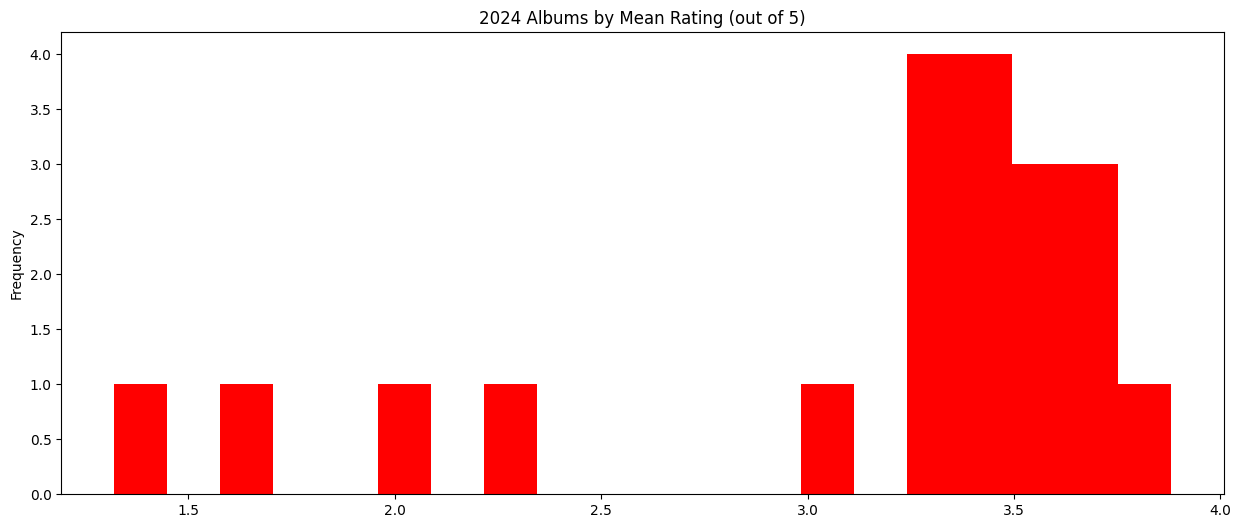

In [28]:
print(mb_album_data['rating_mean'].astype(float).describe())
mb_album_data['rating_mean'].astype(float).plot.hist(bins=20, figsize=(15, 6), color='r', title=f'{YEAR} Albums by Mean Rating (out of 5)')


<Axes: title={'center': '2024 Albums by Playcount Total'}, ylabel='Frequency'>

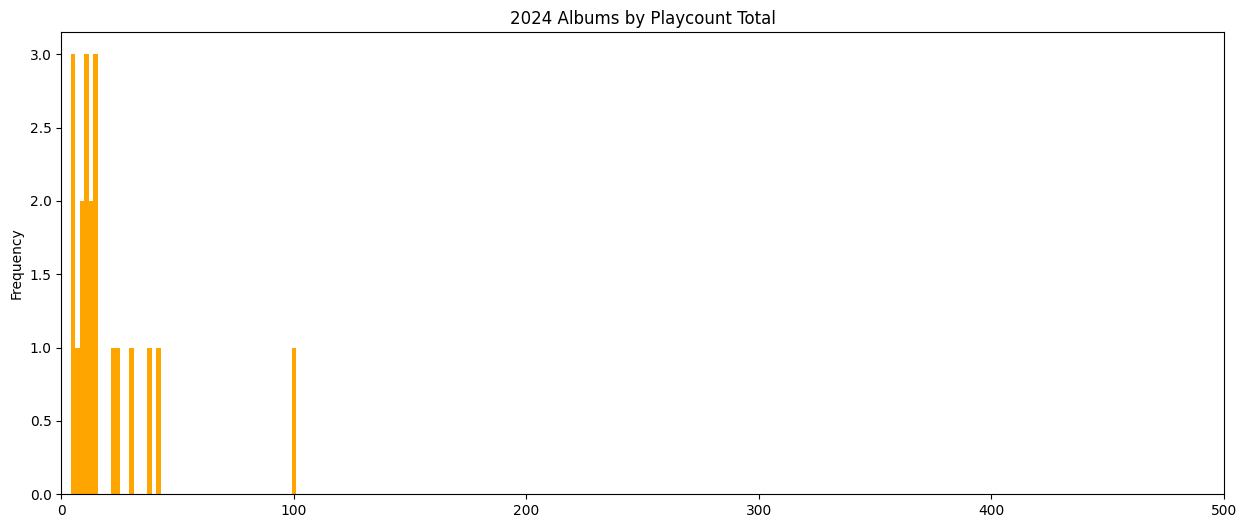

In [29]:
mb_album_data['total_track_playcount'].plot.hist(bins=50, xlim=(0, 500), figsize=(15, 6), color='orange', title=f'{YEAR} Albums by Playcount Total')